# **Creación de data tabular de la señales fisiológicas obtenidas de EMG y ECG**

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
plt.style.use("ggplot")
array1 = np.genfromtxt("./señal ecg1.txt", delimiter=",",skip_header = 2)
array2 = np.genfromtxt("./señal ecg2.txt", delimiter=",",skip_header = 2)

array1[:,0] = np.arange(0, len(array1[:,0]))
basal1 = array1[500:1500,1]
inhex5s = array1[3500:4500,1]
basal2 = array1[7500:8500,1]
array2[:,0] = np.arange(0, len(array2[:,0]))
reposoburp = array2[1500:3500,1]
inhexburp = array2[36000:38000,1]

Fs = 100
def plotear(array:np.ndarray,title:str,Fs:int=Fs):
    Ts=1/Fs
    n = np.arange(0,array.shape[0])  # t = n*Ts
    t = n*Ts
    plt.figure(figsize=(13,2))
    plt.title(title)
    plt.xlabel("Tiempo(s)")
    plt.plot(t, array)

def fftplot(signal,Fs):
    N = 2**10                                     # 10 bits, 0-1023

    signal_fft = np.fft.fft(signal, N)           # fft magtinud
    signal_fft = np.round(np.abs(signal_fft),3)[0:N//2] # nos quedamos con los componente de la derecha de la FFT
    signal_aux = signal_fft/signal_fft.max()     # hallamos el maximo para pasar la magnitud a escala db

    with np.errstate(divide='ignore'):
        signal_fft_db = 10*np.log10(signal_aux)  # , out=signal_aux, where=signal_aux >= 0 para evitar division por zero

    F_list = np.linspace(0,Fs/2, N//2)
    F = np.round(F_list[np.argmax(signal_fft_db)], 1)   # argmax, encuentra el argumento max en un array

    plt.figure()
    plt.plot(F_list, signal_fft_db)  #10 * np.log10(P / Pref) , decibelios
    plt.text(F,0, f"{F}Hz")
    plt.grid(linestyle=":")
    plt.ylabel("Magnitud (db)")
    plt.xlabel("Frecuencias (Hz)")
    plt.title("FFT en decibelios")
    plt.xlim([0,50])
    plt.xticks(np.arange(0,50,10))
    plt.show()


def deefe(array:np.ndarray,ntarget:int,col:int=100,Fs:int=Fs) -> tuple[np.ndarray, np.ndarray]:
  Ts=1/Fs
  n = np.arange(0,array.shape[0])  # t = n*Ts
  t = n*Ts

  #Pasamos las observaciones a filas correspondientes a una variable t y d_sensor
  st_sensor = np.concatenate((t.reshape(-1,1),  array.reshape(-1,1)), axis=1)
  #Creamos el data frame con las varibles t y d_sensor
  df = pd.DataFrame(st_sensor, columns=["t","d_sensor"])
  df.head()
  #Establecemos t como index 
  df = df.set_index("t")

  d_obs = df[["d_sensor"]].values.reshape(int(array.shape[0]/col),col)
  target = np.repeat(ntarget, d_obs.shape[0])
  return d_obs,target

obs_basal1,target_basal1=deefe(basal1,0)
obs_inhex5s,target_inhex5s=deefe(inhex5s,1)
obs_basal2,target_basal2=deefe(basal2,2)

obs_reposoburp,target_reposoburp=deefe(reposoburp,3)
obs_inhexburp,target_inhexburp=deefe(inhexburp,4)

ecg = {"base": np.concatenate([obs_basal1,obs_inhex5s,obs_basal2,obs_reposoburp,obs_inhexburp]), "target": np.concatenate([target_basal1,target_inhex5s,target_basal2,target_reposoburp,target_inhexburp])}
type(ecg["base"])

numpy.ndarray

| Descripción | Categoría |
|----------|----------|
|Basal 1                    |0|
|Inhalación y exhalación    |1|
|Basal 2                    |2|
|Reposo 1                   |3|
|Reposo 2                   |4|

* **Basal 1:** Primera medición en reposo basal.
* **Inhalación y exhalación:** Ciclo de repeticiones de inhalación y exhalación, con un aguante de 5 segundos por proceso.
* **Basal 2:** Segunda medición en reposo basal.
* **Reposo 1:** Medición del reposo inmediatamente después del ejercicio de alta exigencia.
* **Reposo 2:** Medición del reposo 3 mintos después del ejercicio de alta exigencia.

# **Análisis ECG**

In [2]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
import pandas as pd 
from scipy.fft import fft
import scipy.signal as signal
from math import log10

**SE OBTIENE EL DATASET**




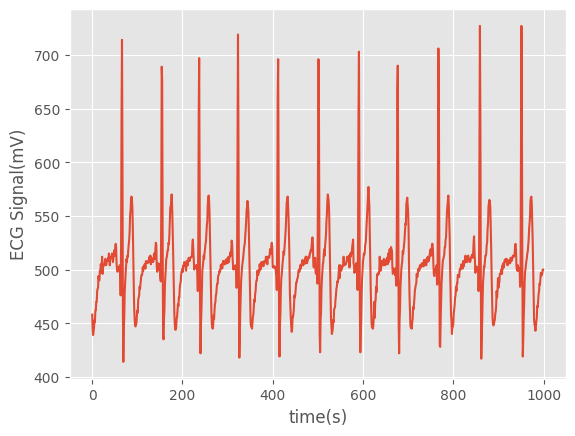

In [3]:
# A numpy
ecg_signal = np.concatenate(ecg['base'][np.where(ecg['target'] == 0)[0]])
plt.plot(ecg_signal)
plt.ylabel('ECG Signal(mV)')
plt.xlabel('time(s)')
plt.show()

**SE ANALIZA LA SEÑAL EN FRECUENCIA**

Conociendo los datos de adquisición de la señal, analicemos ahora el espectro de Fourier.

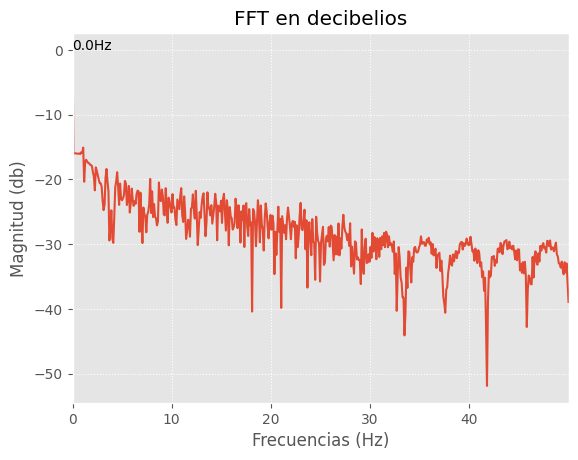

In [4]:
# Analizar el Fourier
fftplot(ecg_signal,100)

## Filtros Notch

En el gráfico anterior, existe un ruido en 50 Hz y armónicos en 150 HZ. Por lo tanto, se debe filtrar.

Se propone utilizar filtros digitales Notch

(No se utiliará debido a que la frecuencia de muestreo utilizada fue de 100Hz)


In [5]:
# # Utilizar filtros Notch para quitar frecuencias que hagan ruido
# from scipy.signal import iirnotch, lfilter
# fs = 1/T  # Frecuencia de muestreo (Hz)
# f0 = 50.0  # Frecuencia que queremos filtrar (Hz)
# Q = 20.0  # Factor de Calidad
# # Diseño de filtro notch
# b, a = iirnotch(f0, Q, fs)
# y = lfilter(b, a, ecg_senal)
# y = lfilter(b, a, y)
# fs = 1/T  # Frecuencia de muestreo (Hz)
# f0 = 150.0  # Frecuencia que queremos filtrar (Hz)
# Q = 7.0  # Factor de Calidad
# # Diseño de filtro notch
# b, a = iirnotch(f0, Q, fs)
# y = lfilter(b,a,y)
# plt.figure(figsize=(20,5))
# #plt.xlim(0,200)
# plt.plot(mtime,y)
# plt.show()

Regresamos a verificar las atenuaciones de los filtros en frecuencia

In [6]:
# # Analisis de Fourier de los filtros
# # Periodo de 2ms (0.002s) o frecuencia de 500 Hz
# T = 0.002
# N = len(y)
# yf = fft(y)
# xf = np.linspace(0.0, 1.0/(2.0*T), N//2)
# plt.figure(figsize=(20,10))
# plt.plot(xf, 2.0/N * np.abs(yf[0:N//2]))
# plt.grid()
# plt.xlabel("Frecuencia")
# plt.ylabel("Magnitud")
# plt.show()
# ecg_signal = y

## **FILTRADO DE PASA BANDA**

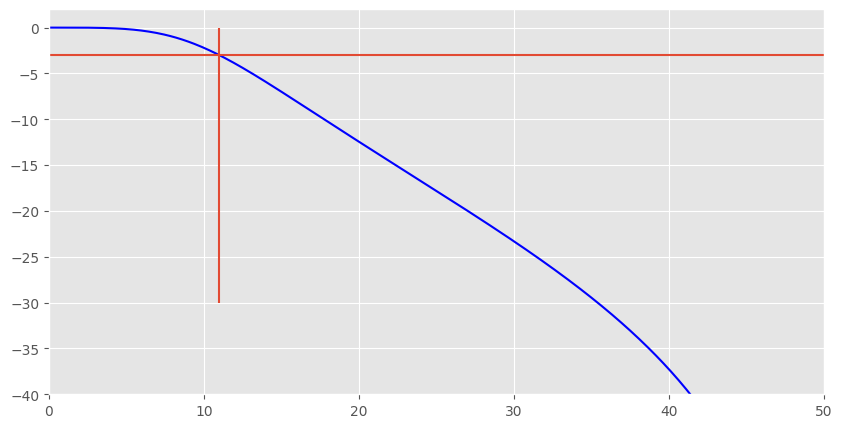

In [7]:
from scipy.signal import freqz, iirdesign, iirfilter, find_peaks
from scipy.signal import iirnotch, lfilter
# 2. filtro pasa banda
# Sub filtro pasa bajo
b, a = iirfilter(2, 11.0, btype='lowpass', rs=3, ftype='butter', fs=100)
w, h = freqz(b, a, fs=100)
plt.figure(figsize=(10,5))
plt.plot(w, 20 * np.log10(abs(h)), 'b')
plt.hlines(-3,0,250)
plt.xlim(0,50)
plt.vlines(11, -30, 0)
plt.ylim(-40,2)
plt.show()

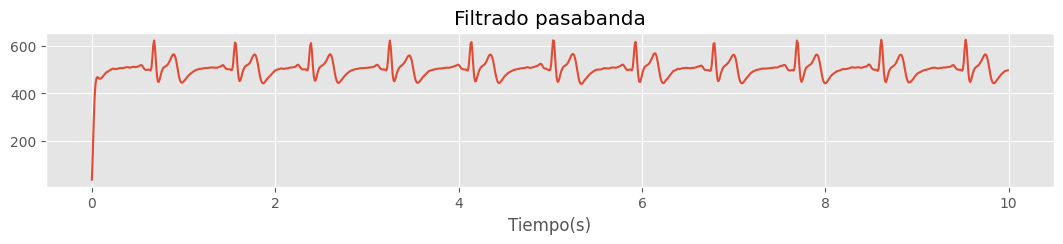

In [8]:
fpb_signal = lfilter(b, a, ecg_signal)
plotear(fpb_signal,"Filtrado pasabanda",100)

## **FILTRO PASA ALTO**

C:\Users\David Campos\AppData\Local\Temp\ipykernel_14564\2196980651.py:4: RuntimeWarning: divide by zero encountered in log10
  plt.plot(w, 20 * np.log10(abs(h)), 'b')


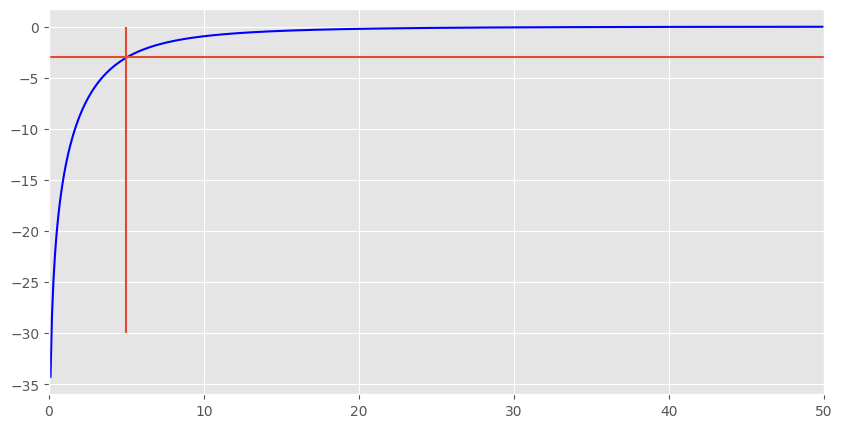

In [9]:
b, a = iirfilter(1, 5.0, btype='highpass', rs=3, ftype='butter', fs=100)
w, h = freqz(b, a, fs=100)
plt.figure(figsize=(10,5))
plt.plot(w, 20 * np.log10(abs(h)), 'b')
plt.hlines(-3,0,250)
plt.xlim(0,50)
plt.vlines(5, -30, 0)
plt.show()


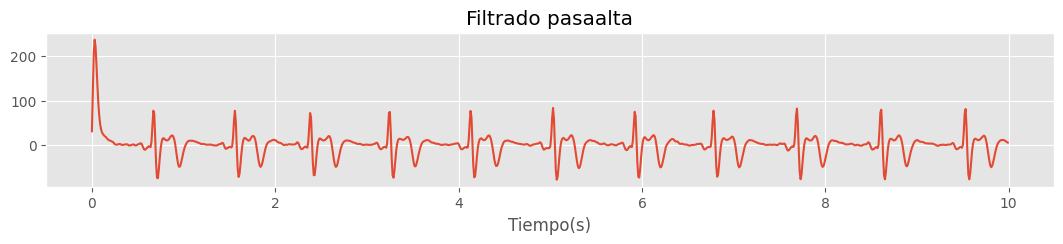

In [10]:
fpa_signal = lfilter(b, a, fpb_signal)
plotear(fpa_signal,"Filtrado pasaalta",100)

## **OPERADOR DERIVATIVO**

En el artículo nos dan la siguiente función que describe al operador:

y[n]=(1/8)(−x[n−2]−2x[n−1]+2x[n+1]+x[n+2])

Para que esta ecuación pueda ser utilizada necesitamos encuadrarla en un rango de  [0,+∞]  haciendo que  n=+2  entonces tenemos:

y[n]=(1/8)(−x[n]−2x[n+1]+2x[n+3]+x[n+4]) 

Por lo tanto:

b=[−1,−2,0,2,1]

C:\Users\David Campos\AppData\Local\Temp\ipykernel_14564\1823615301.py:6: RuntimeWarning: divide by zero encountered in log10
  plt.plot(w, 20 * np.log10(abs(h)), 'b')


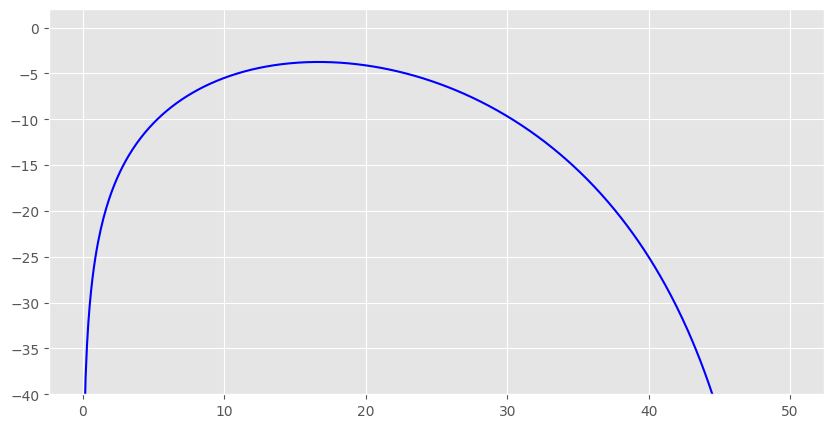

In [11]:
# Filtro derivativo
b = np.array([-1, -2, 0, 2, 1])
b = (1/8)*b
w, h = freqz(b, 1, fs=100)
plt.figure(figsize=(10,5))
plt.plot(w, 20 * np.log10(abs(h)), 'b')
# plt.xlim(0,250)
plt.ylim(-40,2)
plt.show()

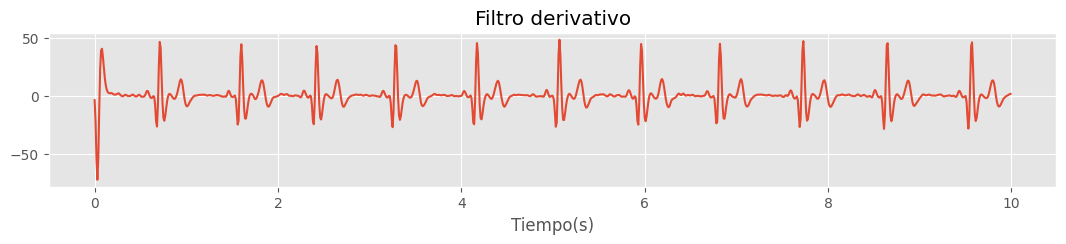

In [12]:
fd_signal = lfilter(b, 1, fpa_signal)
plotear(fd_signal,"Filtro derivativo",100)

## **OPERADOR CUADRÁTICO**

Este operador solo tiene como función elevar al cuadrado los valores de la señal.

y[n]=x^2[n]

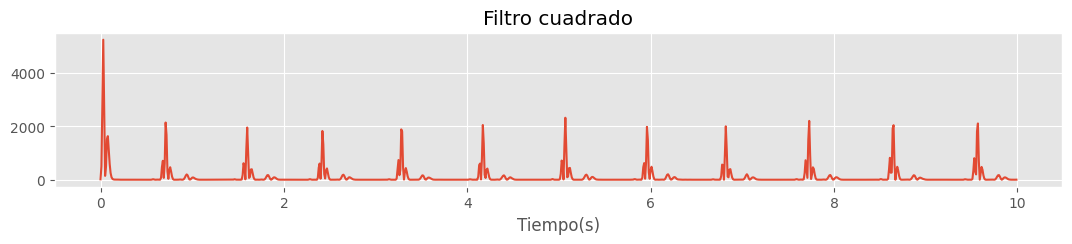

In [13]:
# Filtro cuadrado
f_sq = np.square(fd_signal)
plotear(f_sq,"Filtro cuadrado",100)

## **OPERADOR MOVING WINDOW INTEGRATION**

Este operador tiene como función extraer ciertas características de la onda.

y[n]=(1/N)(x[n−(N−1)]+x[n−(N−2)]+..+x[n])

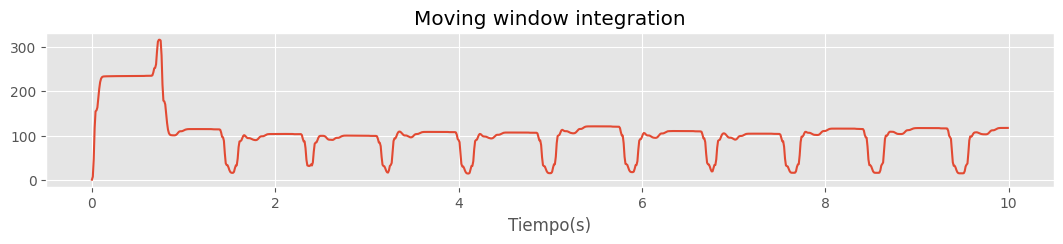

In [14]:
# Moving-Window Integration
N = 75
b = np.ones(N-1)
b = (1/N)*b
fi_signal = lfilter(b, 1, f_sq)
plotear(fi_signal,"Moving window integration",Fs)

Colocando marcadores en los picos

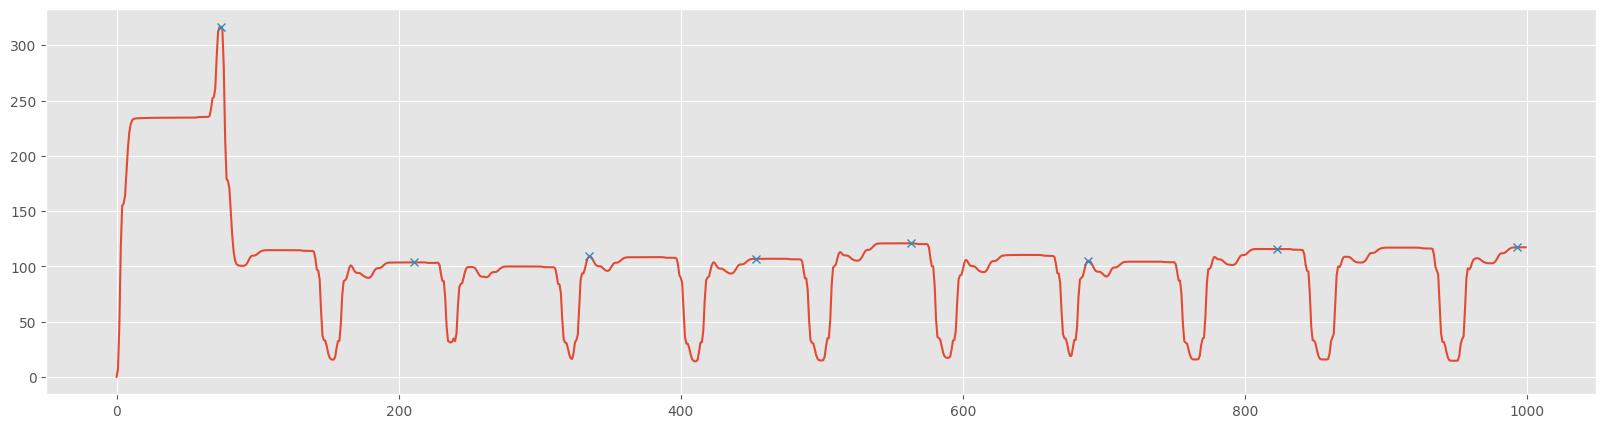

In [15]:
# Fiducial Marks
peaks, _ = find_peaks(fi_signal, distance=100)
plt.figure(figsize=(20,5))
plt.plot(fi_signal)
plt.plot(peaks, fi_signal[peaks], "x")
plt.show()

## **ANÁLISIS DE THRESHOLD**

El valor del umbral de pico R de entrada es  79.17267963606197
El valor del umbral de ruido de entrada es  68.45650591201249


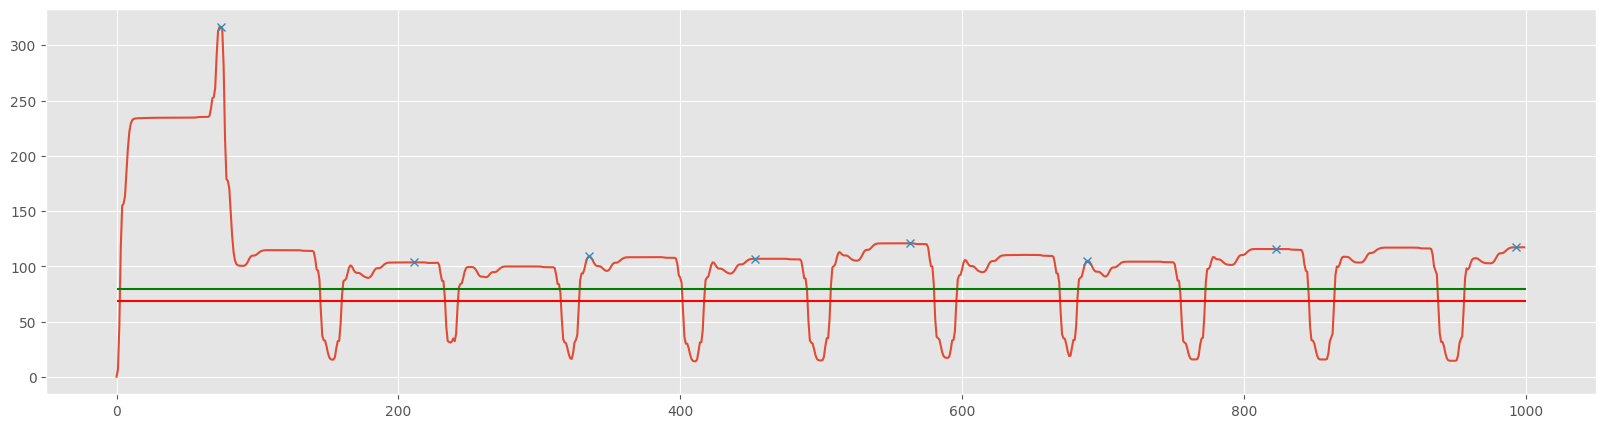

In [16]:
# Training Part to set Threshold I1 and Threshold I2
# Para las primeras muestras en 2 segundos
# Para efectos del ejercicio vamos a analizar toda la señal
f_samples = len(peaks)
th_I1 = np.max(fi_signal[peaks[:f_samples]])*0.25
th_I2 = 0.5*np.mean(fi_signal[peaks[:f_samples]])
print ("El valor del umbral de pico R de entrada es ", th_I1)
print ("El valor del umbral de ruido de entrada es ", th_I2)
plt.figure(figsize=(20,5))
plt.plot(fi_signal)
#plt.xlim(50,1000)
plt.plot(peaks, fi_signal[peaks], "x")
plt.hlines(th_I1, 0, len(fi_signal), colors='green')
plt.hlines(th_I2, 0, len(fi_signal), colors='red')
plt.show()

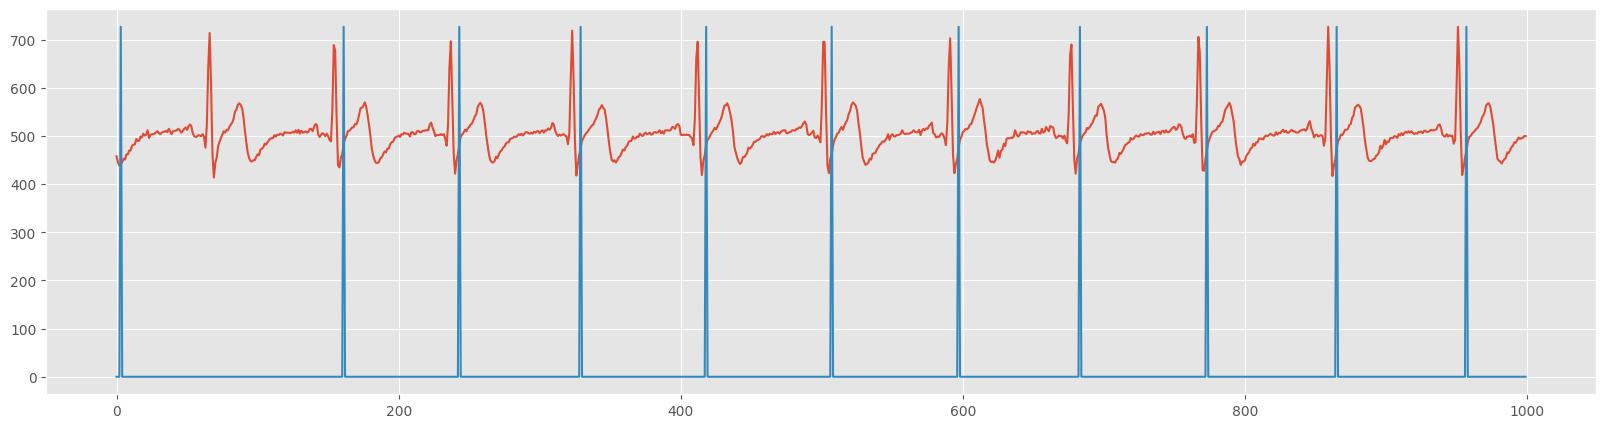

In [17]:
end_qrs = fi_signal > th_I1
roll_qrs_r = np.roll(end_qrs, 1)
roll_qrs_l = np.roll(end_qrs, -1)
end_qrs = np.logical_xor(end_qrs ,roll_qrs_r)
end_qrs = np.logical_and(end_qrs ,roll_qrs_l)
plt.figure(figsize=(20,5))
# plt.xlim(0,500)
plt.plot(ecg_signal)
plt.plot(end_qrs*np.max(ecg_signal))
plt.show()

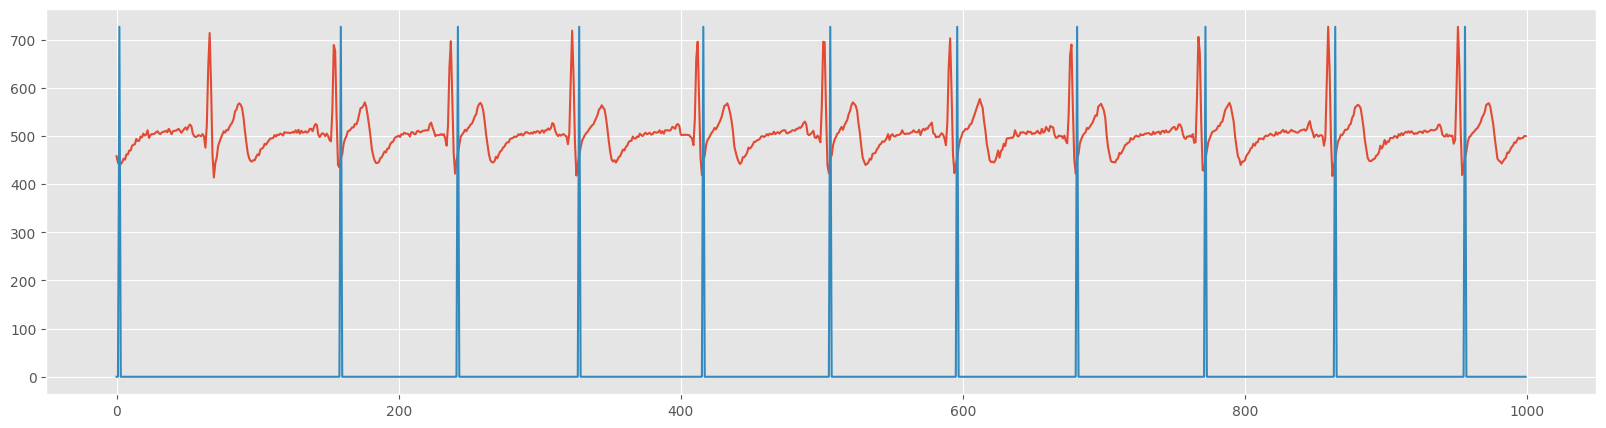

In [18]:
start_qrs = fi_signal < th_I2
roll_qrs_l = np.roll(start_qrs, -1)
roll_qrs_r = np.roll(start_qrs, 1)
start_qrs = np.logical_xor(start_qrs ,roll_qrs_l)
start_qrs = np.logical_and(start_qrs ,roll_qrs_r)
plt.figure(figsize=(20,5))
plt.plot(ecg_signal)
# plt.xlim(0,500)
plt.plot(start_qrs*np.max(ecg_signal))
plt.show()

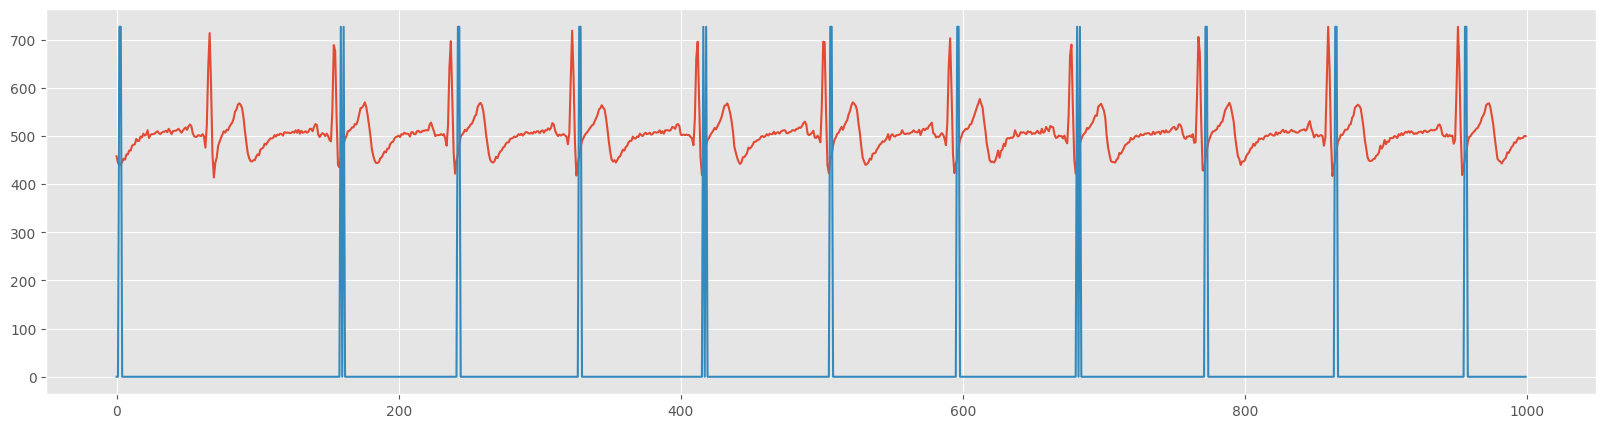

In [19]:
qrs = np.logical_or(start_qrs, end_qrs)
plt.figure(figsize=(20,5))
# plt.xlim(4000,5000)
plt.plot(ecg_signal)
plt.plot(qrs*np.max(ecg_signal))
plt.show()


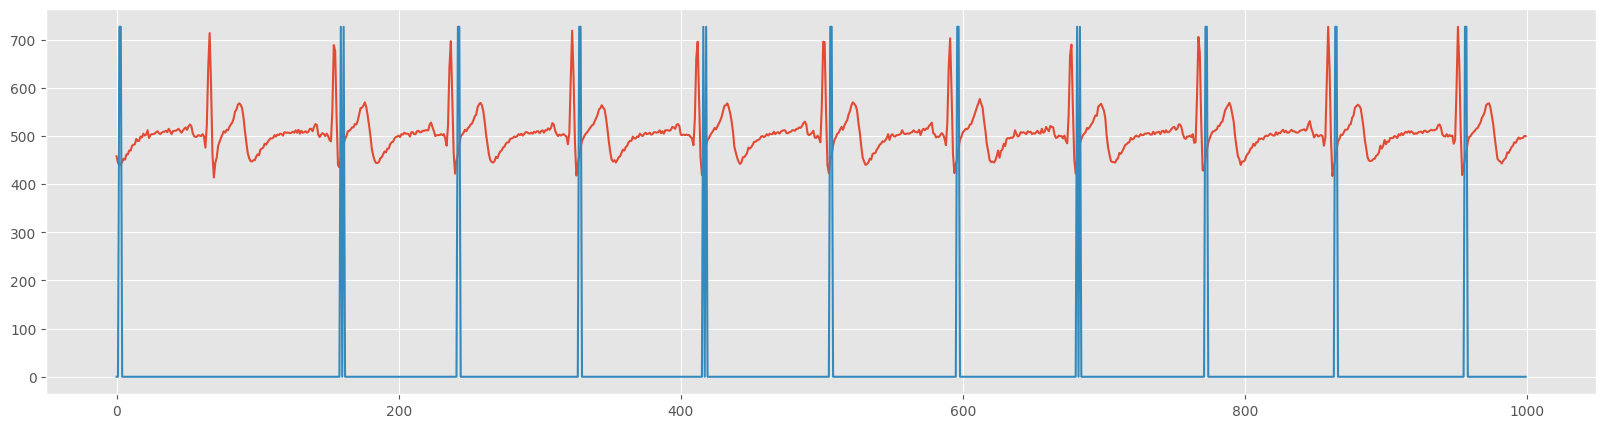

In [20]:
qrs = np.logical_or(start_qrs, end_qrs)
plt.figure(figsize=(20,5))
plt.plot(ecg_signal)
plt.plot(qrs*np.max(ecg_signal))
plt.show()